# Galaxy System

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# astropy
from astropy.io import fits
from astropy.wcs import WCS
# reprojection
from reproject import reproject_interp



In [58]:
#directory of the fits file 
directory = "/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/S0121+3848/"
# data cubes and mask 
#data_cube = fits.getdata(directory + "S0116+4114_HIcube2_clean_image_4_cube.fits")
#mask_cube = fits.getdata(directory + "S0116+4114_HIcube2_clean_image_4_mask.fits")
# smooth data 
data_cube_smooth = fits.getdata(directory + "S0116+4114_HIcube2_clean_smooth_image_4_cube.fits")
mask_cube_smooth = fits.getdata(directory + "S0116+4114_HIcube2_clean_smooth_image_4_mask.fits")

In [59]:
# inspect the header 
header = fits.getheader(directory + "S0116+4114_HIcube2_clean_smooth_image_4_cube.fits")


In [60]:
header

SIMPLE  =                    T                                                  
BITPIX  =                  -32                                                  
NAXIS   =                    3                                                  
NAXIS1  =                   75                                                  
NAXIS2  =                   63                                                  
NAXIS3  =                   71                                                  
CTYPE1  = 'RA---TAN'                                                            
CRPIX1  =    6.26500000000E+02                                                  
CDELT1  =   -1.66666700000E-03                                                  
CRVAL1  =    1.90320943370E+01                                                  
CTYPE2  = 'DEC--TAN'                                                            
CRPIX2  =    4.78500000000E+02                                                  
CDELT2  =    1.66666700000E-

In [26]:
# inspect data dimension
print("Data cube shape:", data_cube_smooth.shape)
# the first axis is the velocity axis, the second and third axes are the spatial axes (RA and Dec)
print("Mask cube shape:", mask_cube_smooth.shape)


Data cube shape: (71, 63, 75)
Mask cube shape: (71, 63, 75)


In [27]:
# ctype 3 is in frequency, we need to convert it to velocity
# we can use the formula: v = c * (f - f0) / f0
# where c is the speed of light, f is the frequency, and f0 is the rest frequency of the HI line (1420.40575 MHz)
c = 299792.458 # speed of light in km/s
f0 = 1420.40575 # rest frequency of the HI line in MHz
f = header['CRVAL3'] + np.arange(header['NAXIS3']) * header['CDELT3'] # frequency array in HZ
f =f / 1e6 # convert frequency to MHz
v = c * (f - f0) / f0 # velocity array in km/s

In [28]:
v.shape

(71,)

In [29]:
# apply mask to the data cube
masked_data_smooth=np.where(mask_cube_smooth,data_cube_smooth,0)

In [30]:
print(v[1]-v[-0])
print(header['CDELT3'])

7.729289824377702
36621.09375


In [31]:
mom0_dat_smooth = np.nansum(masked_data_smooth,axis=0) * (v[1] - v[0]) # km/s


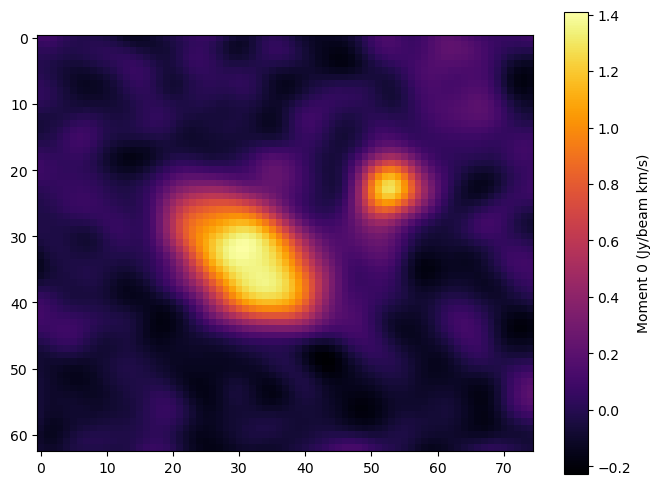

In [32]:
plt.figure(figsize=(8, 6))
plt.imshow(mom0_dat_smooth, cmap='inferno')
plt.colorbar(label='Moment 0 (Jy/beam km/s)')
plt.show()

Let's do the overlay with the optical image

In [33]:
data_optical = fits.getdata(directory + "S0116-4114-sdssg-optical.fits")
header_optical = fits.getheader(directory + "S0116-4114-sdssg-optical.fits")

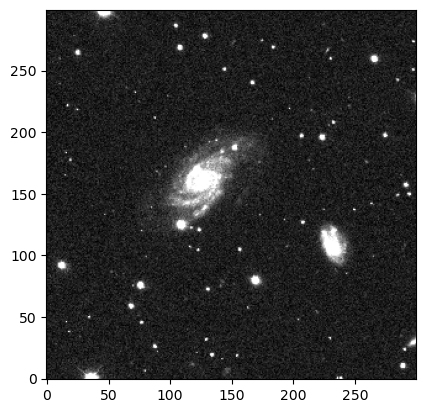

In [34]:
plt.imshow(data_optical, cmap='gray', origin='lower', vmin=np.percentile(data_optical, 1), vmax=np.percentile(data_optical, 99))

In [35]:
# overlay the HI moment 0 map on the optical image
wcs_header = WCS(header).celestial
wcs_optical = WCS(header_optical).celestial

hi_reprojected, footprint = reproject_interp((mom0_dat_smooth, wcs_header), wcs_optical)
rms_mom0 = np.sqrt(np.nanmean(hi_reprojected**2))

hi_levels = np.linspace(rms_mom0, np.nanmax(hi_reprojected), 10)

In [36]:
print(np.nanmax(hi_reprojected), np.nanmin(hi_reprojected), rms_mom0)
print(hi_levels)

1.4092750768485025 -0.22666489889676103 0.3457907054480692
[0.34579071 0.46395564 0.58212057 0.7002855  0.81845043 0.93661536
 1.05478029 1.17294522 1.29111015 1.40927508]


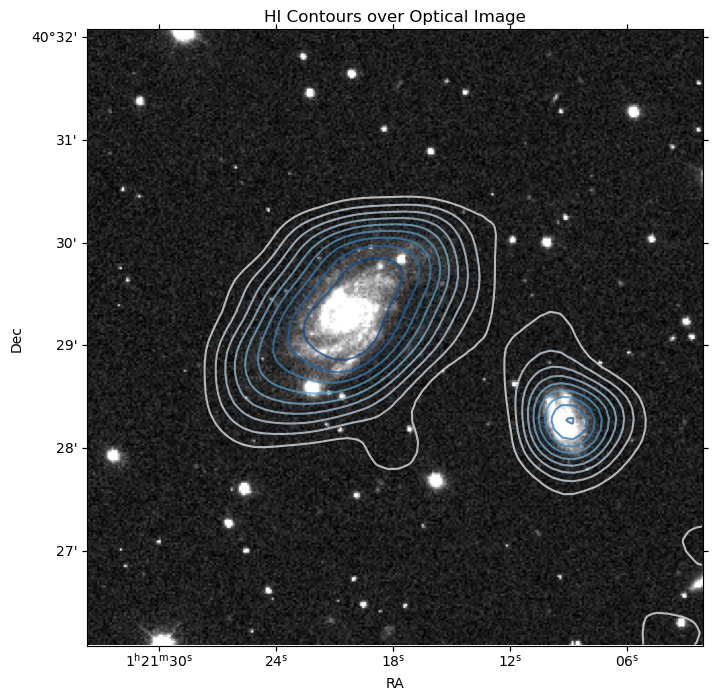

In [37]:

hi_levels = np.linspace(0.5*rms_mom0, np.nanmax(hi_reprojected), 10)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection=wcs_optical)
ax.imshow(data_optical, cmap='gray', origin='lower', vmin=np.percentile(data_optical, 1), vmax=np.percentile(data_optical, 99))
ax.contour(hi_reprojected, levels=hi_levels, cmap='Blues', alpha=0.7)
ax.set_xlabel('RA')
ax.set_ylabel('Dec')
ax.set_title('HI Contours over Optical Image')
plt.show()

Let's set the radius of the galaxy for BBarolo modelling

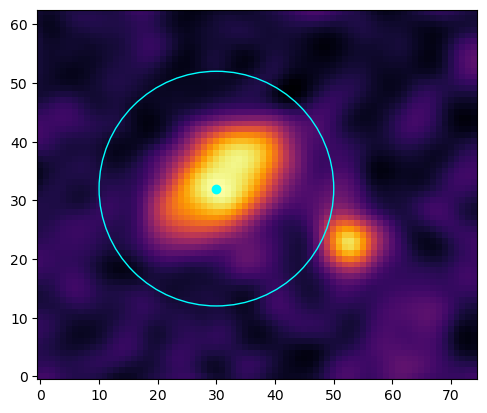

In [38]:
plt.imshow(mom0_dat_smooth, cmap='inferno', origin='lower')
plt.plot(30,32,'o',color='cyan')
plt.gca().add_patch(plt.Circle((30, 32), 20, color='cyan', fill=False))

We need to define how many rings give to BBarolo to model the disk of the galaxy:  
    \*NRADDI: how many ring from the center to the edge of the galaxy  
    \*RADSEP: How far apart (in arcseconds) the rings are from each other

In [47]:
BMAJ = header['BMAJ'] # in degrees
BMIN = header['BMIN'] # in degrees
# transform to arcsecdons (Because BBarolo accept values in arcs)
BMAJ_arcsec = BMAJ * 3600
BMIN_arcsec = BMIN * 3600
print("Beam major axis (arcsec):", BMAJ_arcsec)
print("Beam minor axis (arcsec):", BMIN_arcsec)

Beam major axis (arcsec): 40.00000096872
Beam minor axis (arcsec): 40.00000096872


In [48]:
# we want ring every 1 beam size
Radsep= BMAJ_arcsec/4.5 # 2 rings per beam size
print("Ring separation (arcsec):", Radsep)

Ring separation (arcsec): 8.88888910416


After chossing RADSEP we can compute NRADII

In [49]:
galaxy_radius = 24 # in pixels, estimated from the plot
Nradii= galaxy_radius / Radsep
print("Number of rings:", Nradii)

Number of rings: 2.6999999346114016


In [50]:
center_x, center_y = 30, 32 
radius = 18

nz ,ny ,nx = data_cube_smooth.shape
y, x = np.ogrid[:ny, :nx]
dist_from_center = np.sqrt((x - center_x)**2 + (y - center_y)**2)
mask2d = (dist_from_center <= radius).astype(int)

# Expand mask to all channels
mask3d = np.broadcast_to(mask2d, data_cube_smooth.shape)

# Apply mask to isolate gas in the circel for all channels  
masked_gas_cube = data_cube_smooth * mask3d

In [51]:
# Now the same for the mask 

nz, ny, nx = mask_cube_smooth.shape
Y, X = np.ogrid[:ny, :nx]
dist_from_center = np.sqrt((X - center_x)**2 + (Y - center_y)**2)
mask2d = (dist_from_center <= radius).astype(int)

# Expand mask to all channels
mask3d_mask = np.broadcast_to(mask2d, mask_cube_smooth.shape)

# Apply mask to isolate gas in the circle for all channels
masked_gas_mask = mask_cube_smooth * mask3d_mask

In [52]:
mom0_newdat = np.nansum(masked_gas_cube,axis=0) * (v[1] - v[0]) # km/s

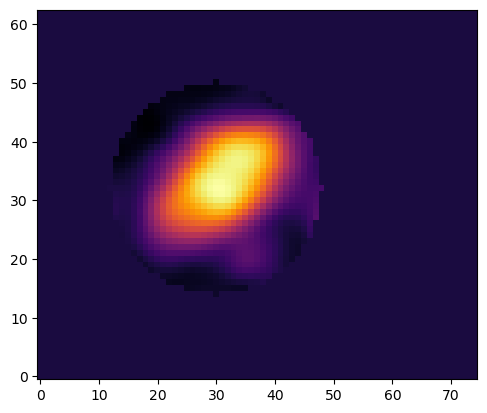

In [53]:
plt.imshow(mom0_newdat, cmap='inferno', origin='lower')

In [54]:
directory = "/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/S0121+3848/"

In [55]:
hdul_new = fits.PrimaryHDU(masked_gas_cube,header=header)
hdul_new.writeto(directory + 'S0121+3848_cube1.fits', overwrite=True)

# save also the mask
hdul_new_mask = fits.PrimaryHDU(masked_gas_mask,header=header)
hdul_new_mask.writeto(directory + 'S0121+3848_mask1.fits', overwrite=True)

## Second Galaxy

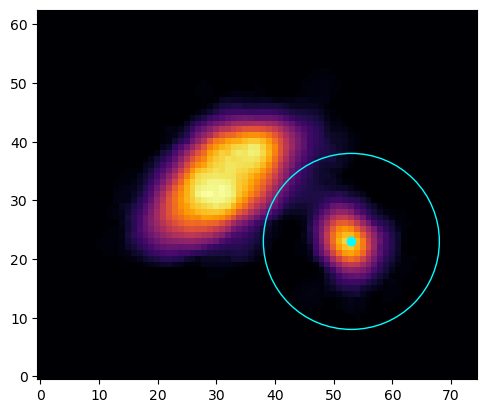

In [ ]:
plt.imshow(mom0_dat_smooth, cmap='inferno', origin='lower')
plt.plot(53,23,'o',color='cyan')
plt.gca().add_patch(plt.Circle((53, 23), 15, color='cyan', fill=False))

In [ ]:
# we want ring every 1 beam size
Radsep2= BMAJ_arcsec/2 # 2 rings per beam size
print("Ring separation (arcsec):", Radsep2)

Ring separation (arcsec): 11.63282557392


In [ ]:
galaxy_radius2 = 20 # in pixels, estimated from the plot
Nradii2= galaxy_radius2 / Radsep2
print("Number of rings:", Nradii2)

Number of rings: 1.7192727487325723


In [ ]:
# Create a binary mask for the circle region on each channel of the data cube

center_x, center_y = 53, 23
radius = 15

nz, ny, nx = data_cube_smooth.shape
Y, X = np.ogrid[:ny, :nx]
dist_from_center = np.sqrt((X - center_x)**2 + (Y - center_y)**2)
mask2d = (dist_from_center <= radius).astype(int)

# Expand mask to all channels
mask3d = np.broadcast_to(mask2d, data_cube_smooth.shape)

# Apply mask to isolate gas in the circle for all channels
masked_gas_cube = data_cube_smooth * mask3d

In [ ]:
# Now the same for the mask 

nz, ny, nx = mask_cube_smooth.shape
Y, X = np.ogrid[:ny, :nx]
dist_from_center = np.sqrt((X - center_x)**2 + (Y - center_y)**2)
mask2d = (dist_from_center <= radius).astype(int)

# Expand mask to all channels
mask3d_mask = np.broadcast_to(mask2d, mask_cube_smooth.shape)

# Apply mask to isolate gas in the circle for all channels
masked_gas_mask = mask_cube_smooth * mask3d_mask

In [ ]:
mom0_newdat=np.nansum(masked_gas_cube, axis=0)*(v[1] - v[0])  # Jy/beam km/s

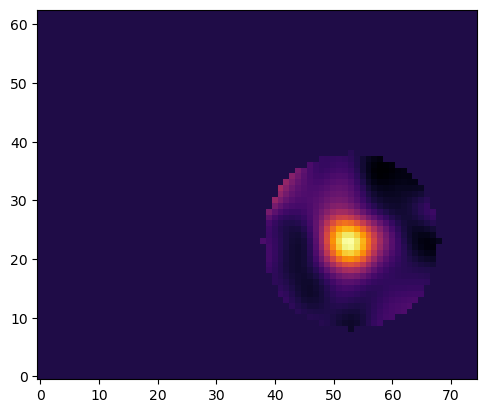

In [ ]:
plt.imshow(mom0_newdat, cmap='inferno', origin='lower')

In [ ]:
directory = "/home/angeldavid/Desktop/Fedora/RESEARCH-INTERSHIPS/data_cubes/S0121+3848-2Galaxy/"

In [ ]:
hdul_new = fits.PrimaryHDU(masked_gas_cube,header=header)
hdul_new.writeto(directory + 'S0121+3848-2GALAXY_cube1.fits', overwrite=True)

# save also the mask
hdul_new_mask = fits.PrimaryHDU(masked_gas_mask,header=header)
hdul_new_mask.writeto(directory + 'S0121+3848-2GALAXY_mask1.fits', overwrite=True)